In [38]:
# importing the libraries that are important for this project 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# importing the dataset
df = pd.read_csv(r"C:\Skills\Student Performance Predictor\Dataset\Students_Performance_dataset.csv")

# Understanding the data

In [48]:
# checking the shape of data
df.shape

(1193, 30)

In [45]:
# we can see there are 1194 rows and 31 collumns now we will see how the data looks like 
df.head(0).T

""
University Admission year
Gender
Age
H.S.C passing year
Current Semester
Do you have meritorious scholarship ?
Do you use University transportation?
How many hour do you study daily?
How many times do you seat for study in a day?
What is your preferable learning mode?


# now we can check the datatypes of the features 

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 30 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1194 non-null   int64  
 1   Gender                                                                     1194 non-null   object 
 2   Age                                                                        1194 non-null   int64  
 3   H.S.C passing year                                                         1194 non-null   int64  
 4   Current Semester                                                           1194 non-null   int64  
 5   Do you have meritorious scholarship ?                                      1194 non-null   object 
 6   Do you use University transportation?                   

In [47]:
# checking the total amount of nul values
df.isnull().sum()

University Admission year                                                    0
Gender                                                                       0
Age                                                                          0
H.S.C passing year                                                           0
Current Semester                                                             0
Do you have meritorious scholarship ?                                        0
Do you use University transportation?                                        0
How many hour do you study daily?                                            0
How many times do you seat for study in a day?                               0
What is your preferable learning mode?                                       0
Do you use smart phone?                                                      0
Do you have personal Computer?                                               0
How many hour do you spent daily in social media?   

In [46]:
# we can see that there is only one missing value 
# now we will check the numerical features of the dataset 
df.dropna(inplace=True)
df.describe()

,University Admission year,Age,H.S.C passing year,Current Semester,How many hour do you study daily?,How many times do you seat for study in a day?,How many hour do you spent daily in social media?,How many hour do you spent daily on your skill development?,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
count,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1.193000e+03
mean,2020.513831,21.345348,2019.213747,6.544007,3.133277,1.940486,3.290025,2.185247,6.715486,7.920641,71.902766,6.252373e+04
std,1.354839,1.612586,1.381352,3.808100,1.649133,0.856663,2.290492,1.296634,2.171206,1.862048,48.049425,7.619556e+04
min,2013.000000,18.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,2020.000000,20.000000,2019.000000,3.000000,2.000000,1.000000,2.000000,1.000000,5.500000,7.250000,23.000000,3.000000e+04
50%,2021.000000,21.000000,2020.000000,7.000000,3.000000,2.000000,3.000000,2.000000,6.700000,8.025000,78.000000,5.000000e+04
75%,2022.000000,22.000000,2020.000000,10.000000,4.000000,2.000000,4.000000,3.000000,8.450000,9.175000,117.000000,7.400000e+04
max,2023.000000,27.000000,2028.000000,24.000000,13.000000,7.000000,20.000000,12.000000,10.000000,10.000000,145.000000,2.000000e+06


In [7]:
# now we can check if there are any duplicate values in the data
df.duplicated().sum()
# there are no duplicated values

np.int64(0)

In [8]:
# we can see the correlation between the numerical collumns 
df.corr(numeric_only=True)

,University Admission year,Age,H.S.C passing year,Current Semester,How many hour do you study daily?,How many times do you seat for study in a day?,How many hour do you spent daily in social media?,How many hour do you spent daily on your skill development?,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
University Admission year,1.000000,-0.650018,0.782228,-0.834406,-0.009701,-0.011147,-0.023836,-0.134997,-0.085830,-0.113261,-0.672899,-0.047732
Age,-0.650018,1.000000,-0.665891,0.585559,-0.012256,0.018433,0.020693,0.121907,0.020770,0.066030,0.476374,0.028034
H.S.C passing year,0.782228,-0.665891,1.000000,-0.579773,0.003068,-0.003386,0.021160,-0.067149,-0.174903,-0.054161,-0.391187,0.025582
Current Semester,-0.834406,0.585559,-0.579773,1.000000,-0.021964,0.040414,0.065189,0.187879,-0.054151,0.177822,0.903204,0.122780
How many hour do you study daily?,-0.009701,-0.012256,0.003068,-0.021964,1.000000,0.374046,0.016313,0.137195,0.043620,0.023696,-0.006609,-0.000492
How many times do you seat for study in a day?,-0.011147,0.018433,-0.003386,0.040414,0.374046,1.000000,-0.063458,0.126989,0.007952,0.048802,0.061102,0.036434
How many hour do you spent daily in social media?,-0.023836,0.020693,0.021160,0.065189,0.016313,-0.063458,1.000000,-0.034756,-0.178530,-0.052876,0.106239,0.053967
How many hour do you spent daily on your skill development?,-0.134997,0.121907,-0.067149,0.187879,0.137195,0.126989,-0.034756,1.000000,0.003063,0.083225,0.185845,0.011152
What was your previous SGPA?,-0.085830,0.020770,-0.174903,-0.054151,0.043620,0.007952,-0.178530,0.003063,1.000000,0.755062,-0.126091,-0.121871
What is your current CGPA?,-0.113261,0.066030,-0.054161,0.177822,0.023696,0.048802,-0.052876,0.083225,0.755062,1.000000,0.222047,-0.000275


In [9]:
# Now we will perform basic Eda To understand our dataframe

# EDA

## Univariate Analysis

In [10]:
df['Program'].value_counts()
# we can see that all the students are from the same program so we can remove the 'Program' column

Program
BCSE    1194
Name: count, dtype: int64

In [11]:
# we removed the collumn which was not required
df = df.drop('Program',axis=1)


In [12]:
df.shape

(1194, 30)

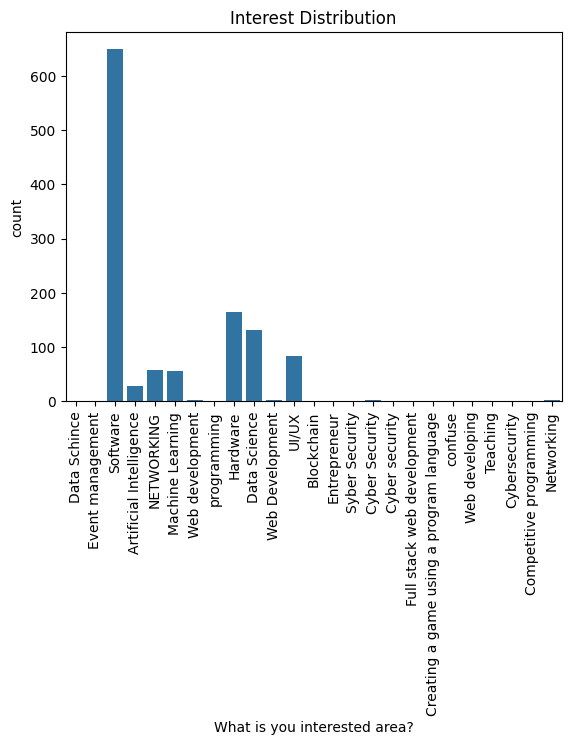

In [13]:
# now we will see that if the Intrested Areas are of how many categories and there distribution
sns.countplot(x=df['What is you interested area?'])
plt.xticks(rotation=90)
plt.title('Interest Distribution')
plt.show()

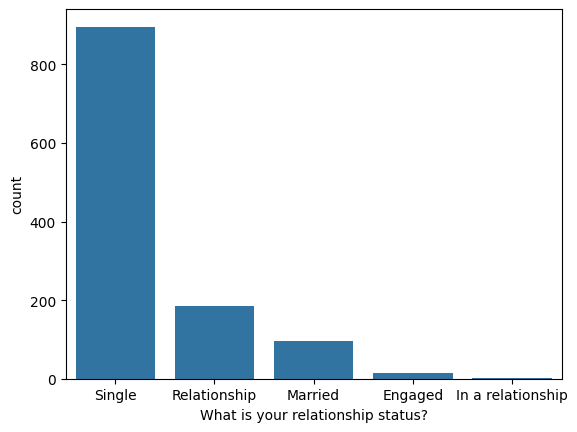

In [14]:
# we can see most of student are in software and ds,AI,hardware,UI/UX etc
# now we can also check relationship status distribution
sns.countplot(x=df['What is your relationship status?'])
plt.show()

In [15]:
# We can see most of the students are Single and some are in relationship but some are maried and engaged too 
# relationship and in a relationship are same so why not combine those two categories 
df['What is your relationship status?'].replace('In a relationship','Relationship',inplace=True)

C:\Users\singl\AppData\Local\Temp\ipykernel_6160\1426986117.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['What is your relationship status?'].replace('In a relationship','Relationship',inplace=True)


In [16]:
# Now we can see if it chenged the useless extra categories into the category we wanted 
df['What is your relationship status?'].value_counts()
# done correctly

What is your relationship status?
Single          896
Relationship    187
Married          96
Engaged          15
Name: count, dtype: int64

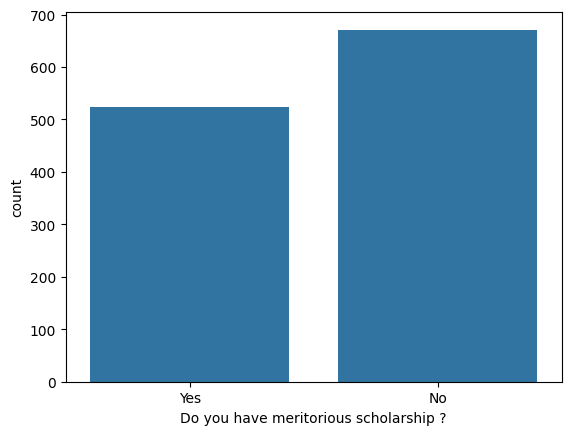

In [17]:
# Now we can see different plots to check the yes no categorical columns 
sns.countplot(x=df['Do you have meritorious scholarship ?'])
plt.show()
# Most students dosent have any scholarship 

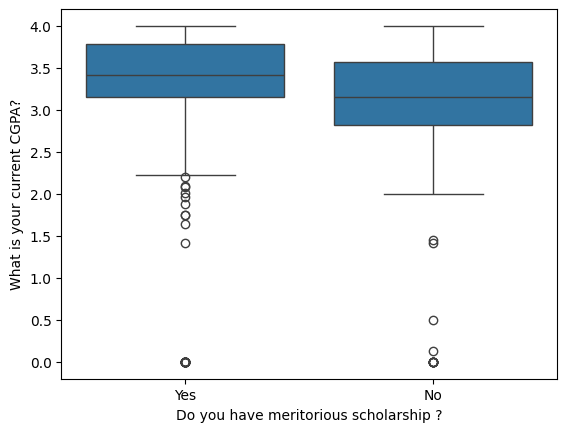

In [18]:
# we will check if this column is actually effecting the target column or not ?
sns.boxplot(x=df['Do you have meritorious scholarship ?'],y=df['What is your current CGPA?'])
plt.show()
# we can clearly see that who have scholarship tend to have higher 

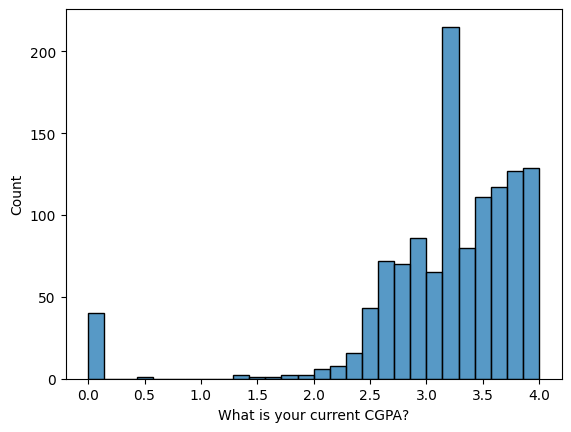

In [19]:
# now we will see the distribution of the target column which is the CGPA
sns.histplot(x=df['What is your current CGPA?'])
plt.show()
# we can see a lot of people got 0 cgpa which maybe outliers of the data 

In [20]:
df['What is your current CGPA?'].describe()
# we can see the average cgpa of the university is 3.16

count    1194.000000
mean        3.165603
std         0.750132
min         0.000000
25%         2.900000
50%         3.210000
75%         3.670000
max         4.000000
Name: What is your current CGPA?, dtype: float64

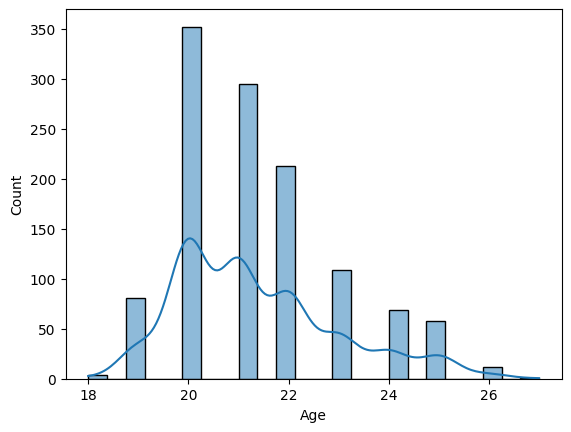

In [21]:
# we can see the age distribution also 
sns.histplot(df['Age'],kde=True)
plt.show()
# most students are around 20 years of age 

In [22]:
# Here we have extra categories that we dont want 
df['Do you have any health issues?'].value_counts()

Do you have any health issues?
No     983
Yes    207
no       3
N        1
Name: count, dtype: int64

In [23]:
df['Do you have any health issues?'].replace('no','No',inplace=True)
df['Do you have any health issues?']=df['Do you have any health issues?'].replace('N','No')

C:\Users\singl\AppData\Local\Temp\ipykernel_6160\3972519480.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Do you have any health issues?'].replace('no','No',inplace=True)


In [24]:
# we corrected the extra categories so that data will be more clean 

In [25]:
# we will check for all categorical columns if there are any values that are given wrong or i can consize some values in the different category
df['What are the skills do you have ?'].value_counts()
# most of the students use and have mobilephone and 
# we can see in skill section bost of the people have no skills but they filled them in different ways so we can combine them and make same 
df['What are the skills do you have ?'] = df['What are the skills do you have ?'].replace({
    'No skills':'None'
    ,'No skill':'None'
    ,'Nothing':'None'
    ,"Haven't started yet":"None"
    ,'No Skill':'None'
    ,'Nothing specially':'None'
    ,'Basic':'None'
    ,'Other':'None'
    ,'Not yet':'None'
    ,'Not Any':'None'
    ,"Don't have any":'None'
    ,'Nothing in this chart':'None'
    ,'I do not know this':'None'
    ,'no skills':'None'
    ,'Trying to learn':'None'
    ,'learner':'None'
    ,'Basic knowledge':'None'
    ,'Its on learning phase':'None'
    ,'Nothing properly':'None'
    ,'Memorizing':'None'
    ,"i don't":'None'
    ,'Nothing much':'None'
    ,'Learning frontend':'None'})

In [26]:
# now checking if other categorical columns have those values which are same 
df['What is you interested area?'].value_counts()
# we can see some things are repeating 2 times 
df['What is you interested area?'] = df['What is you interested area?'].replace({
    'Web development':'Web Development'
    ,'Web developing':'Web Development'
    ,'Cyber security':'Cyber Security'
    ,'Cybersecurity':'Cyber Security'
    ,'Syber Security':'Cyber Security'
    ,'Data Schince':'Data Science'
    ,'Networking':'NETWORKING'
    ,'Competitive programming':'programming' 
})

In [27]:
# we cleaned the categorical columns which had 
# meaning less values now we will do some univariate analysis on numerical column and move to bivariate analysis

In [28]:
counts = df['What are the skills do you have ?'].value_counts()
# there are too many skills in the what skills do you have section so we ject just put the rest of the skills as others 
counts = counts[counts<23].index

In [29]:
df['What are the skills do you have ?'] = df['What are the skills do you have ?'].replace(counts,'Others')

In [65]:
df.head().T

,0,1,2,3,4
University Admission year,2018,2021,2020,2021,2021
Gender,Male,Male,Female,Male,Male
Age,24,22,21,20,22
H.S.C passing year,2016,2020,2019,2020,2019
Current Semester,12,4,5,4,4
Do you have meritorious scholarship ?,Yes,Yes,No,Yes,Yes
Do you use University transportation?,No,Yes,No,No,No
How many hour do you study daily?,3,3,3,1,3
How many times do you seat for study in a day?,2,2,3,3,1
What is your preferable learning mode?,Offline,Online,Offline,Offline,Online


In [31]:
# Now we will move on to univariate analysis on numerical columns 
# i want to predict in 10 cgpa scale so i will convert the sgpa and cpga in 10 scale 
df['What is your current CGPA?'] = df['What is your current CGPA?']*2.5
df['What was your previous SGPA?'] = df['What was your previous SGPA?']*2.5

In [32]:
df.sample(5).T

,255,1170,195,359,323
University Admission year,2019,2020,2019,2021,2021
Gender,Female,Female,Female,Male,Male
Age,23,24,21,20,20
H.S.C passing year,2018,2018,2018,2020,2020
Current Semester,11,9,11,2,3
Do you have meritorious scholarship ?,Yes,No,Yes,Yes,Yes
Do you use University transportation?,No,Yes,No,No,No
How many hour do you study daily?,4,3,5,3,2
How many times do you seat for study in a day?,2,3,2,1,2
What is your preferable learning mode?,Online,Offline,Offline,Offline,Offline


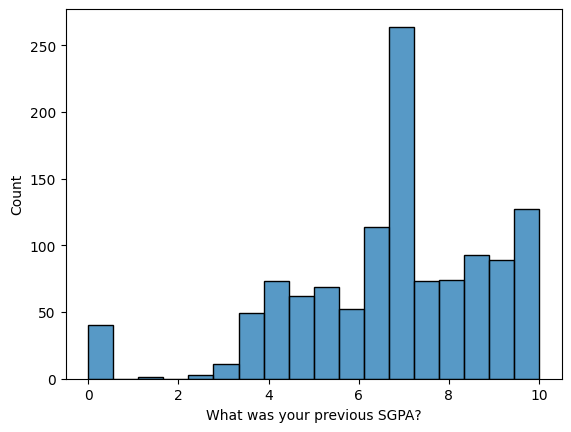

In [33]:
sns.histplot(df['What was your previous SGPA?'])
plt.show()

In [34]:
df.describe()

,University Admission year,Age,H.S.C passing year,Current Semester,How many hour do you study daily?,How many times do you seat for study in a day?,How many hour do you spent daily in social media?,How many hour do you spent daily on your skill development?,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1.194000e+03
mean,2020.515075,21.343384,2019.214405,6.539363,3.131491,1.940536,3.289782,2.185092,6.709862,7.914008,71.842546,6.248812e+04
std,1.354954,1.613338,1.380960,3.809884,1.649597,0.856305,2.289547,1.296101,2.178980,1.875330,48.074338,7.617356e+04
min,2013.000000,18.000000,2012.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+03
25%,2020.000000,20.000000,2019.000000,3.000000,2.000000,1.000000,2.000000,1.000000,5.500000,7.250000,23.000000,3.000000e+04
50%,2021.000000,21.000000,2020.000000,7.000000,3.000000,2.000000,3.000000,2.000000,6.700000,8.025000,78.000000,5.000000e+04
75%,2022.000000,22.000000,2020.000000,10.000000,4.000000,2.000000,4.000000,3.000000,8.450000,9.175000,117.000000,7.400000e+04
max,2023.000000,27.000000,2028.000000,24.000000,13.000000,7.000000,20.000000,12.000000,10.000000,10.000000,145.000000,2.000000e+06


In [82]:
# now we can check the skewness of every numerical column 
numcol = df.describe().columns

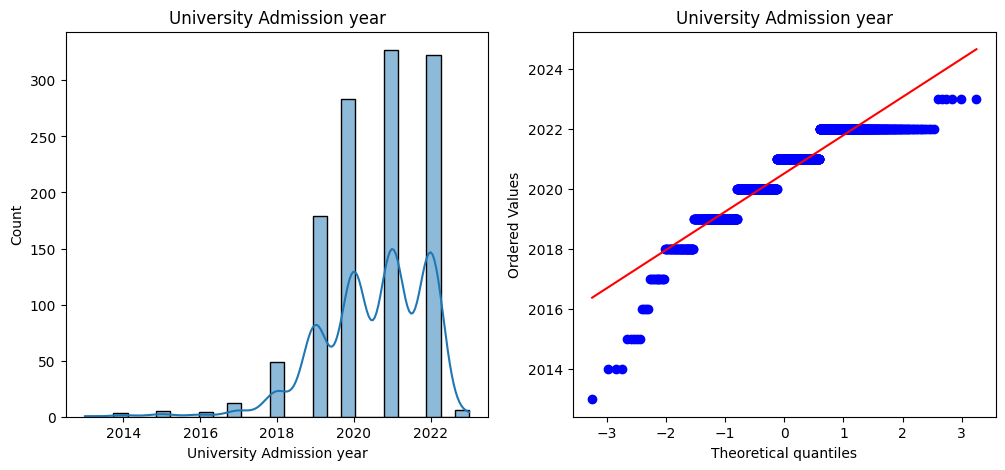

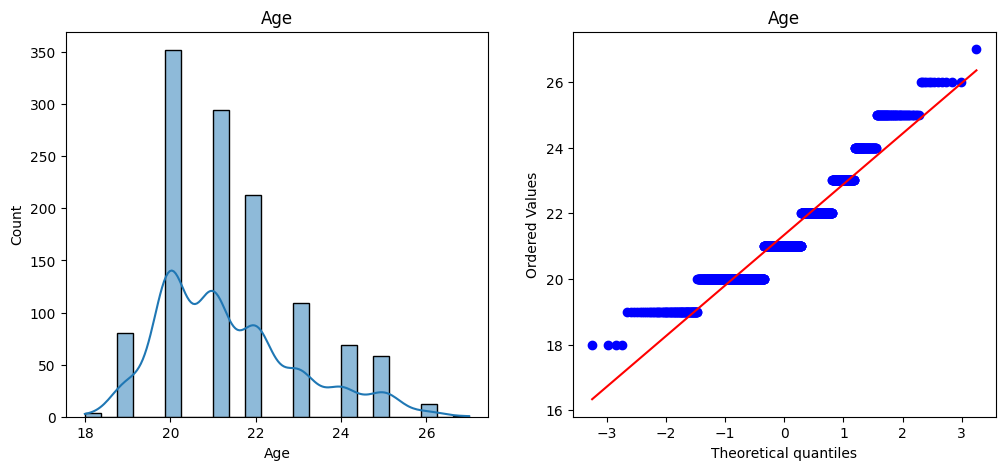

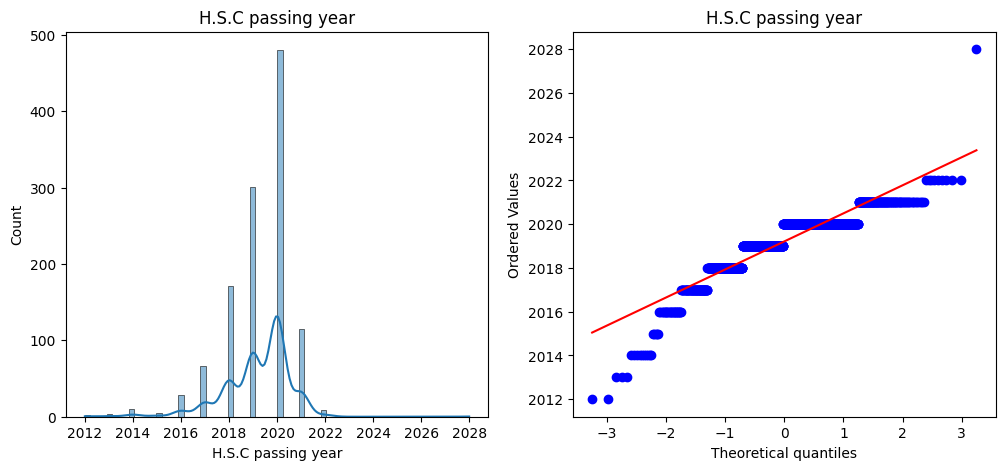

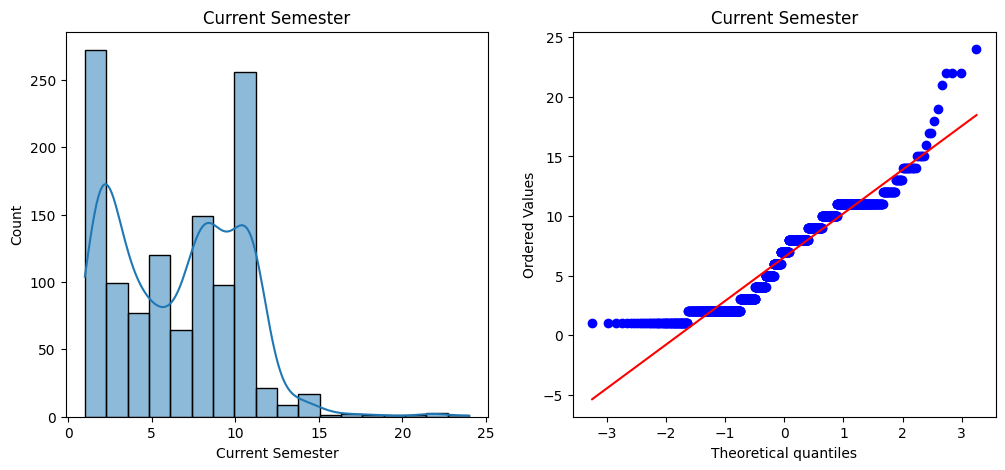

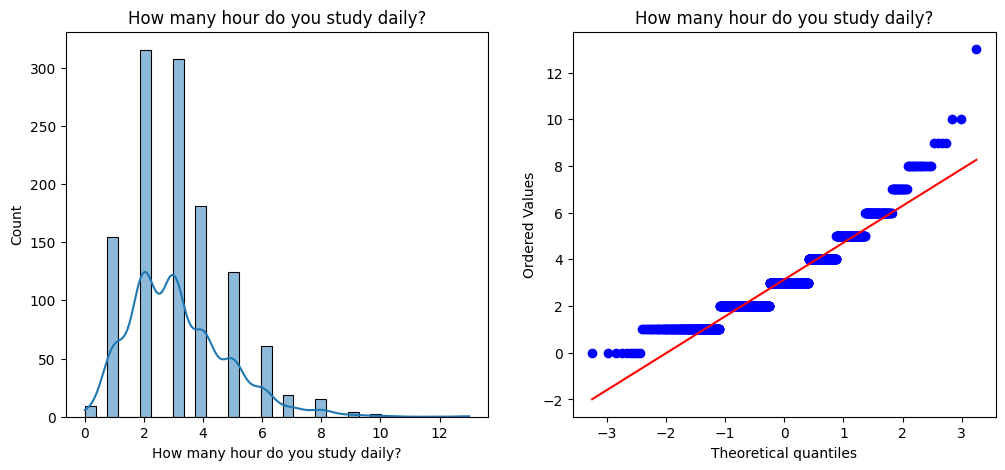

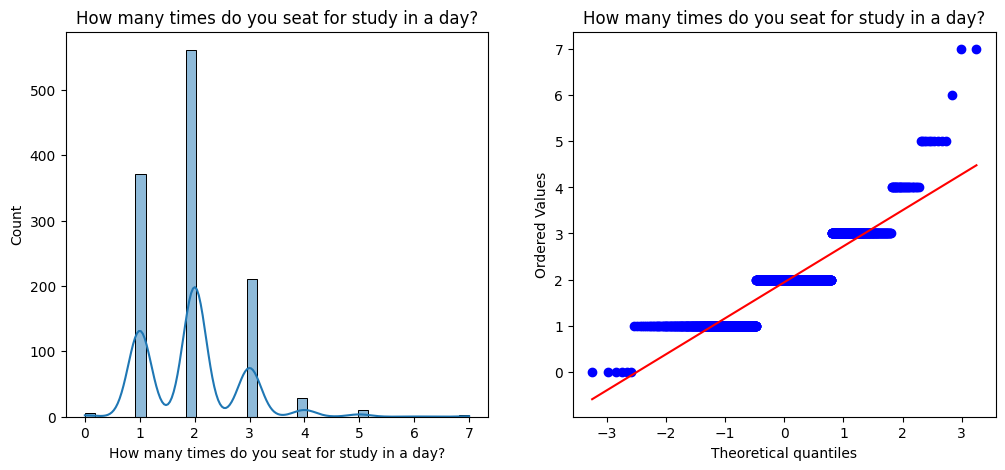

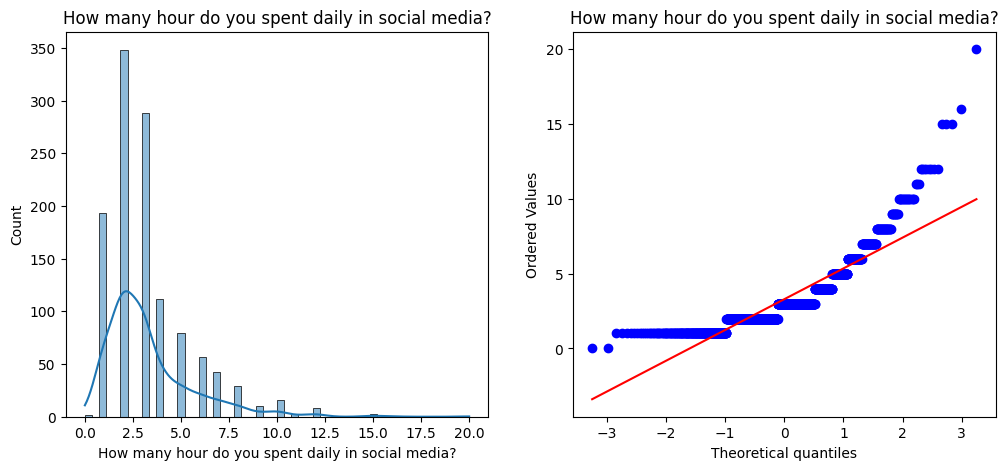

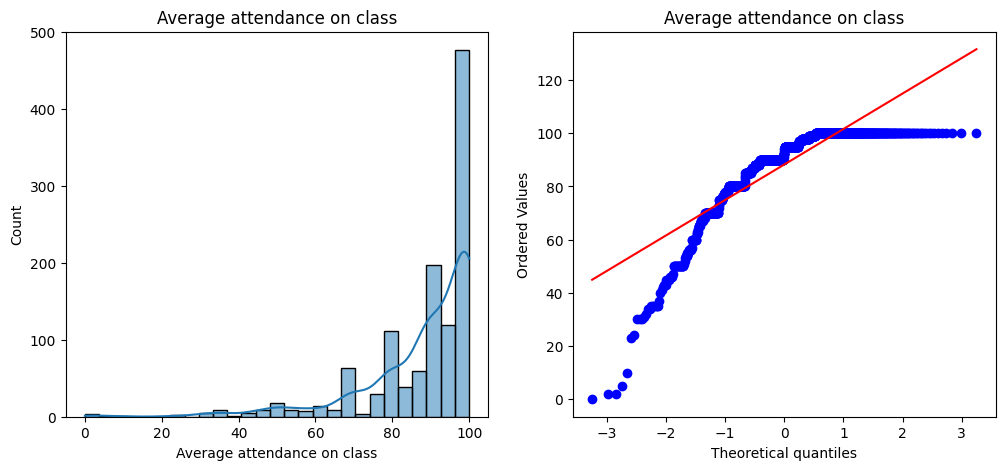

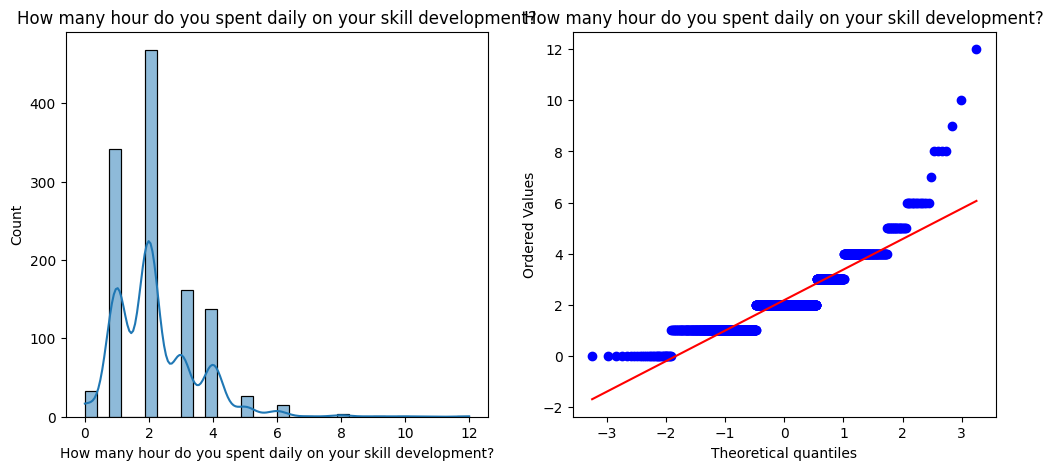

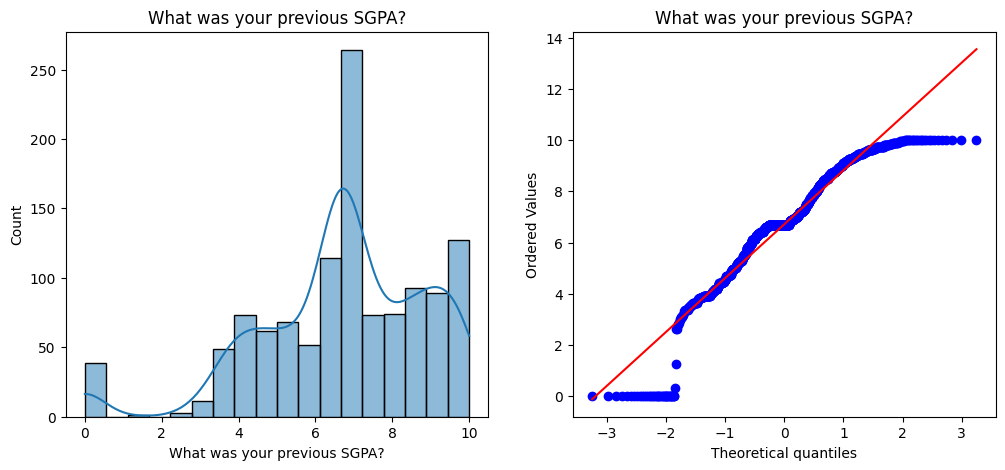

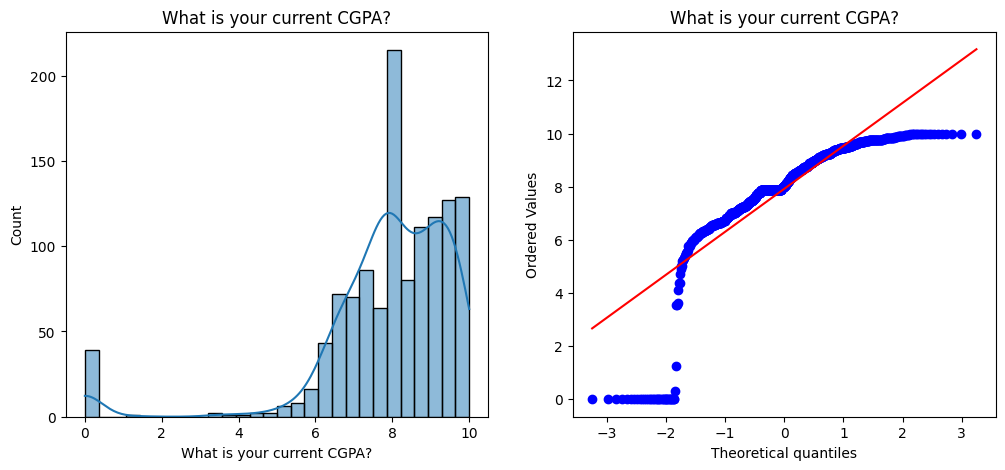

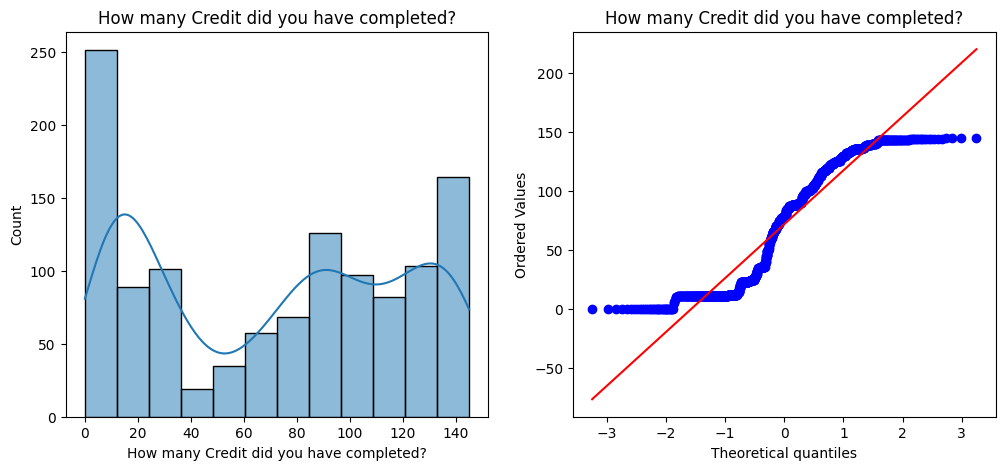

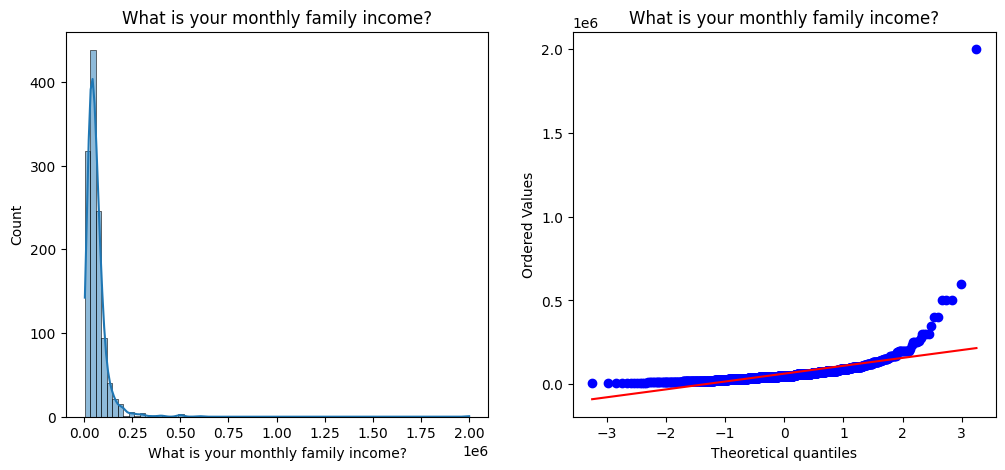

In [83]:
# to check skewness of the data 
for i in numcol:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(df[i],kde=True)
    plt.title(i)

    plt.subplot(122)
    stats.probplot(df[i],plot=plt)
    plt.title(i)

In [93]:
# this gave us an idea of how skewed the data is 
# family income has very big outliers that can destory our model we should handle them properly 
# and the continues data is not thet skewd but has outliers 
# now we can check the skewness of the data 
df[numcol].skew()

University Admission year                                      -1.089486
Age                                                             0.803843
H.S.C passing year                                             -1.104701
Current Semester                                                0.364467
How many hour do you study daily?                               1.005279
How many times do you seat for study in a day?                  1.020211
How many hour do you spent daily in social media?               1.991738
Average attendance on class                                    -2.110554
How many hour do you spent daily on your skill development?     1.558079
What was your previous SGPA?                                   -0.852205
What is your current CGPA?                                     -2.503439
How many Credit did you have completed?                        -0.022489
What is your monthly family income?                            15.074733
dtype: float64

In [50]:
# we now also have how much skewed the data is 
# now we can start our multivariate analysis which will help us understand the data better 

# Multivariate Analysis

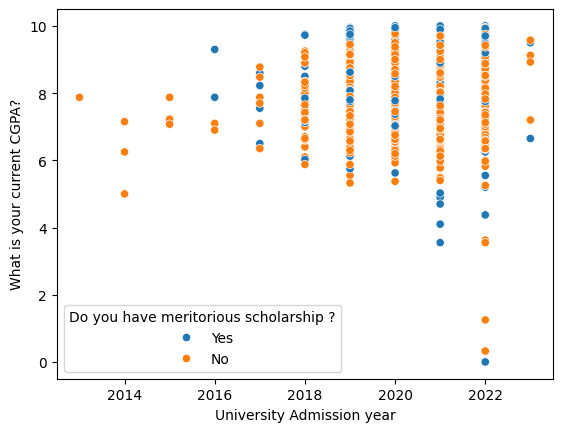

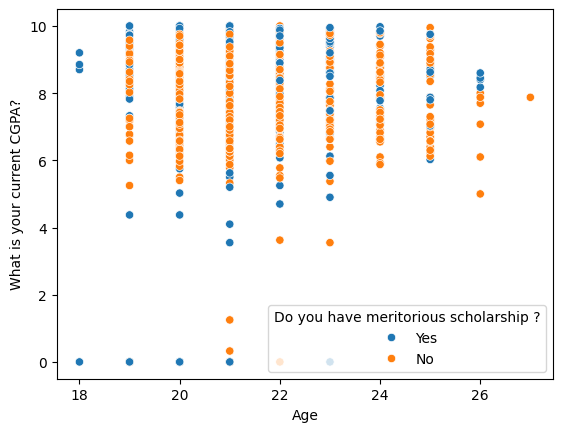

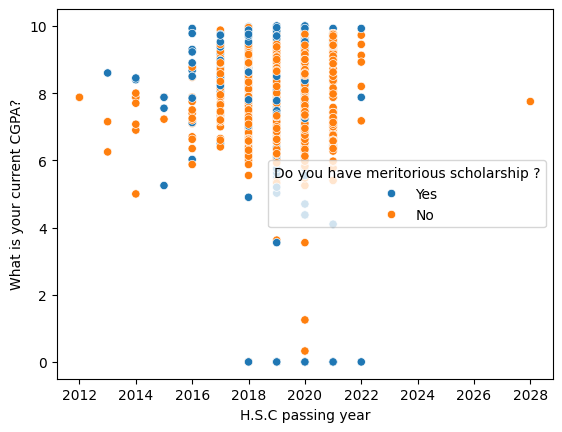

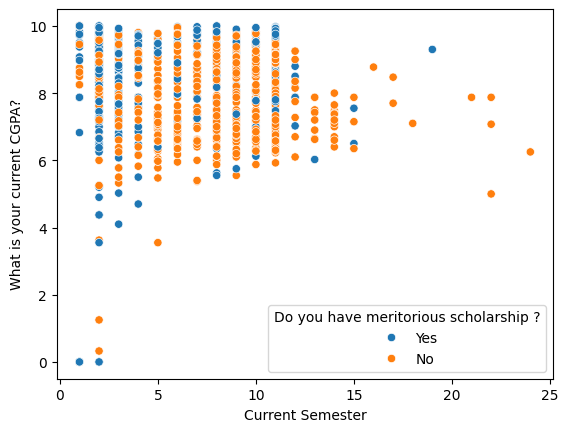

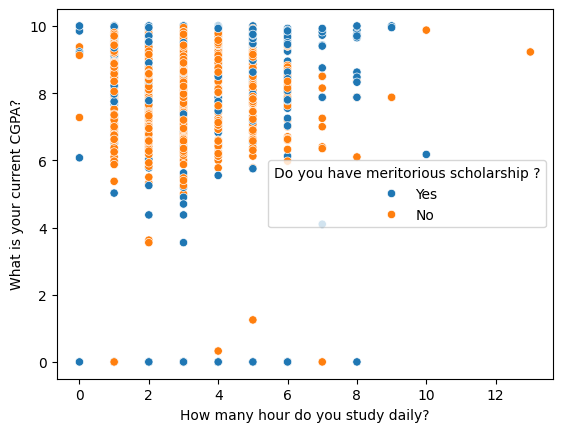

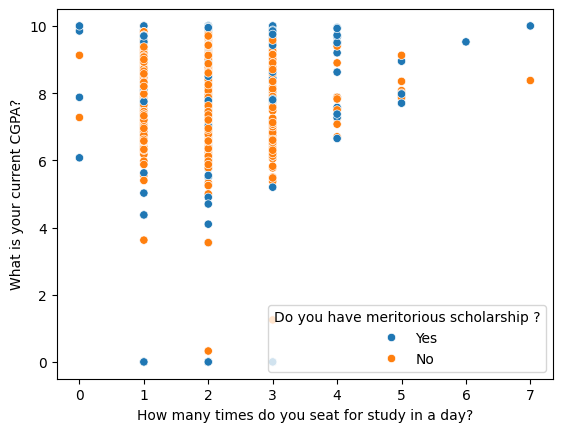

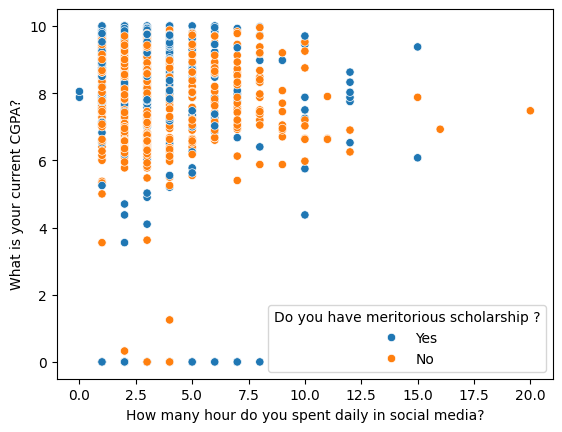

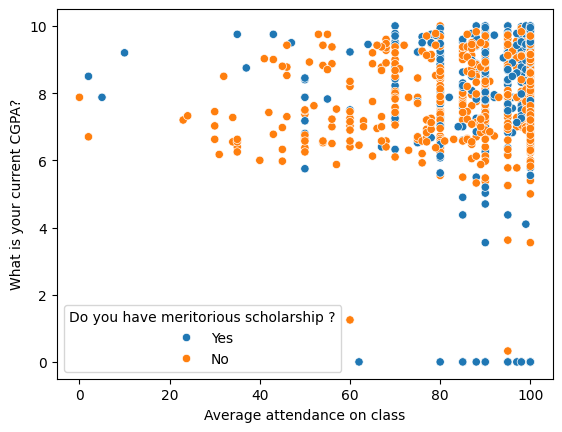

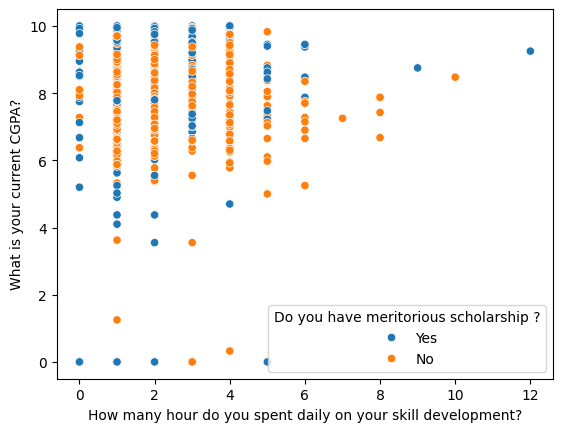

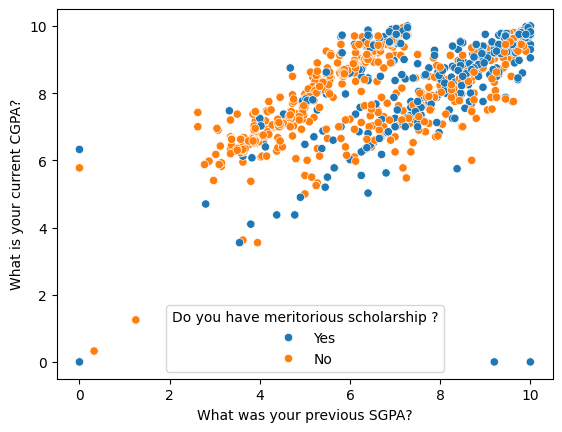

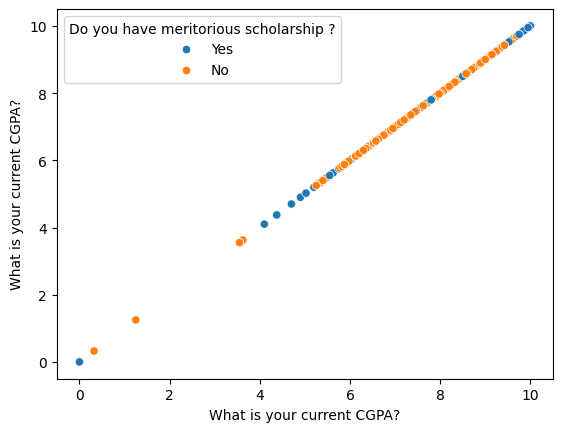

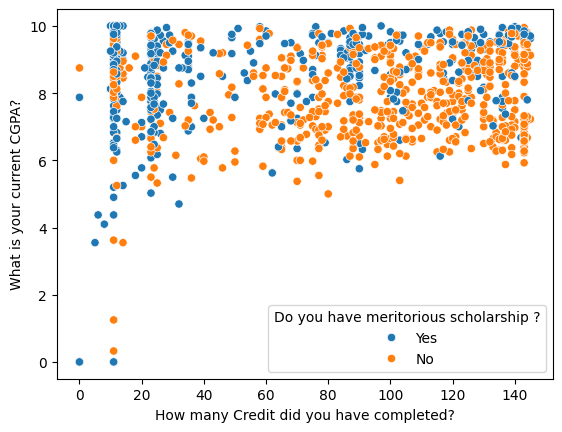

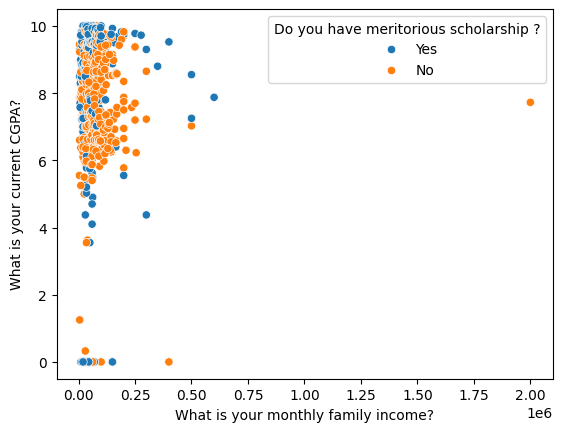

In [85]:
# firstly we will make scatterplots of numerical columns with the target column 
for i in numcol:
    sns.scatterplot(x=df[i],y=df['What is your current CGPA?'],hue=df['Do you have meritorious scholarship ?'])
    plt.show()

In [58]:
# we can see it is dependent most on the Sgpa column and rest of the columns provide very less information about our target column 
# we can also see by hue that some people with scholarship tend to have more cgpa 
# now we can see the box plots of categorical columns with our cgpa 
df.drop(numcol,axis=1)

,Gender,Do you have meritorious scholarship ?,Do you use University transportation?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,Do you have any physical disabilities?
0,Male,Yes,No,Offline,Yes,Yes,Intermediate,90,No,No,Yes,Software Development,Data Science,Single,Yes,Bachelor,No,No
1,Male,Yes,Yes,Online,Yes,Yes,Basic,96,Yes,No,No,Web development,Event management,Single,Yes,Family,No,No
2,Female,No,No,Offline,Yes,Yes,Intermediate,80,No,No,Yes,Programming,Software,Single,No,Bachelor,No,No
3,Male,Yes,No,Offline,Yes,Yes,Intermediate,88,No,No,Yes,Programming,Artificial Intelligence,Single,No,Bachelor,Yes,No
4,Male,Yes,No,Online,Yes,Yes,Intermediate,80,No,No,Yes,Programming,Software,Relationship,No,Bachelor,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189,Female,No,Yes,Online,Yes,Yes,Basic,46,Yes,No,No,Cyber security,Data Science,Relationship,Yes,Bachelor,No,No
1190,Male,Yes,Yes,Offline,Yes,Yes,Basic,100,Yes,No,Yes,Programming,Software,Single,Yes,Bachelor,No,No
1191,Male,No,Yes,Offline,Yes,No,Basic,100,Yes,No,No,Networking,Hardware,Married,Yes,Family,No,No
1192,Female,No,Yes,Offline,Yes,Yes,Intermediate,100,No,No,Yes,Web development,Software,Single,No,Bachelor,No,No


In [73]:
# we can see that the attendance column is shown as a non numerical column which we can change 
df.iloc[457:458,14:15] #there is this one person who put his attendance as a range which is making whole column a string so we will drop this 
df = df.drop(index=457,axis=0)

In [80]:
df['Average attendance on class'] = pd.to_numeric(df['Average attendance on class'])

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1192 entries, 0 to 1193
Data columns (total 30 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   University Admission year                                                  1192 non-null   int64  
 1   Gender                                                                     1192 non-null   object 
 2   Age                                                                        1192 non-null   int64  
 3   H.S.C passing year                                                         1192 non-null   int64  
 4   Current Semester                                                           1192 non-null   int64  
 5   Do you have meritorious scholarship ?                                      1192 non-null   object 
 6   Do you use University transportation?                        

In [88]:
# now we can easily check the categorical features of the data with the tagert column 
categorical = df.drop(numcol,axis=1)

In [89]:
categorical.head()

,Gender,Do you have meritorious scholarship ?,Do you use University transportation?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,Status of your English language proficiency,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,Do you have any physical disabilities?
0,Male,Yes,No,Offline,Yes,Yes,Intermediate,No,No,Yes,Software Development,Data Science,Single,Yes,Bachelor,No,No
1,Male,Yes,Yes,Online,Yes,Yes,Basic,Yes,No,No,Web development,Event management,Single,Yes,Family,No,No
2,Female,No,No,Offline,Yes,Yes,Intermediate,No,No,Yes,Programming,Software,Single,No,Bachelor,No,No
3,Male,Yes,No,Offline,Yes,Yes,Intermediate,No,No,Yes,Programming,Artificial Intelligence,Single,No,Bachelor,Yes,No
4,Male,Yes,No,Online,Yes,Yes,Intermediate,No,No,Yes,Programming,Software,Relationship,No,Bachelor,Yes,No


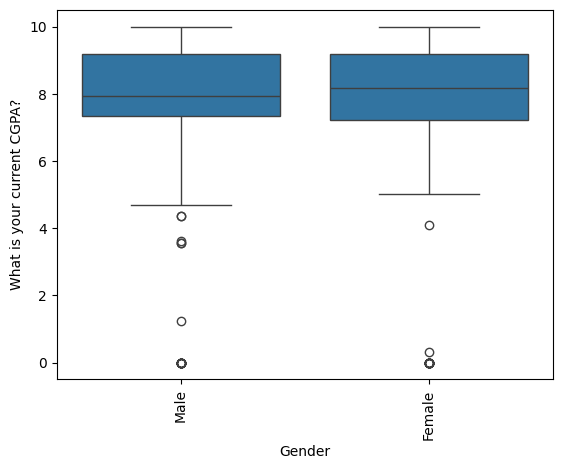

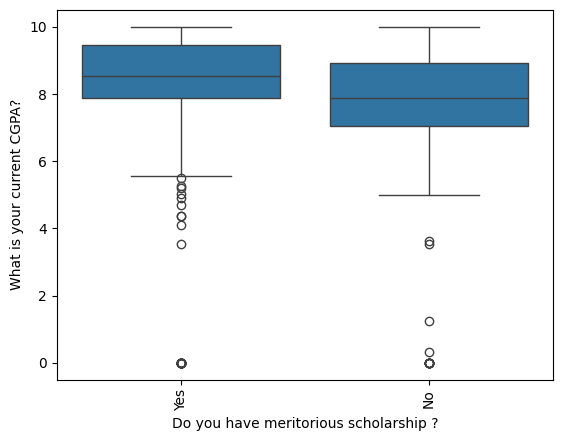

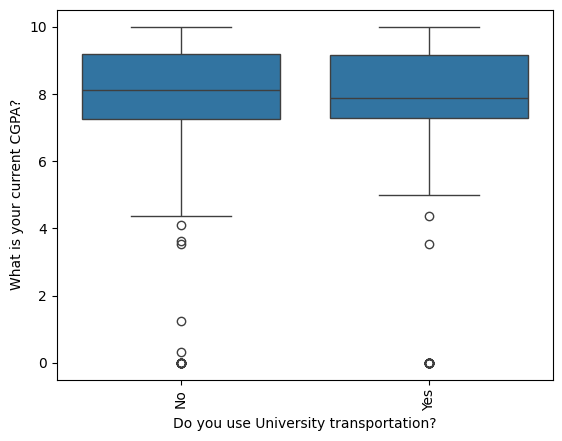

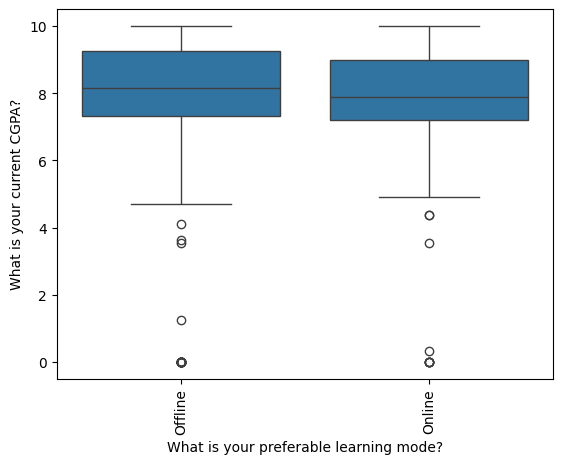

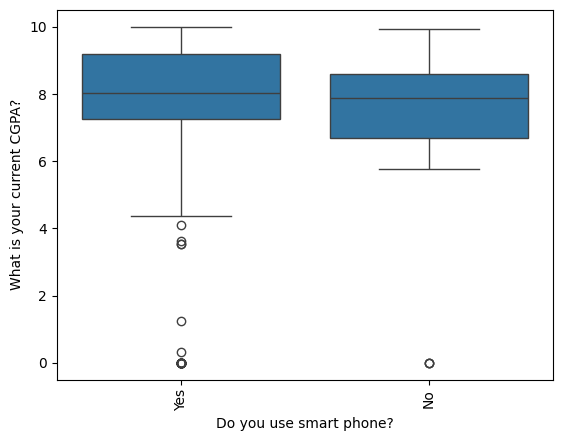

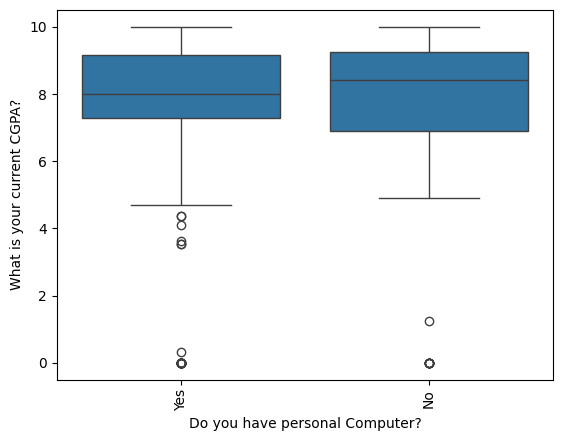

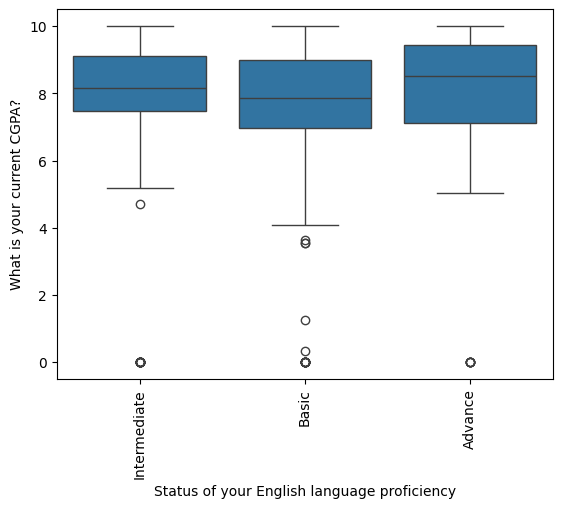

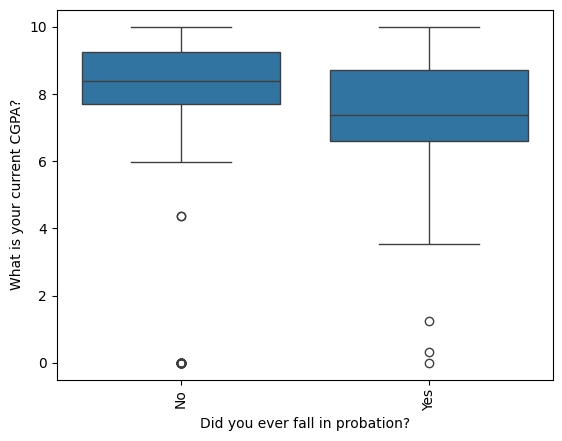

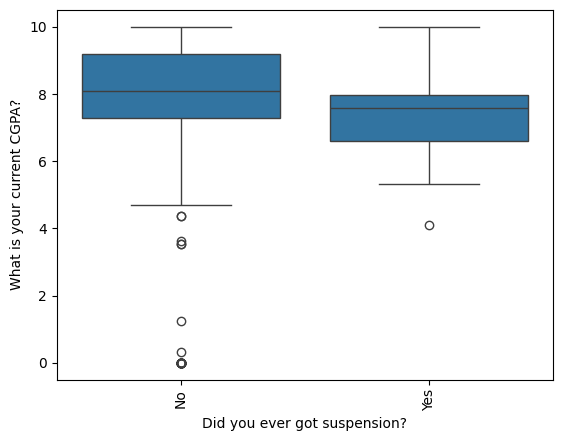

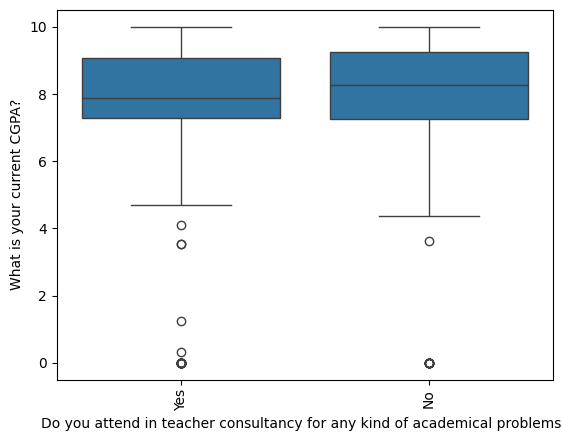

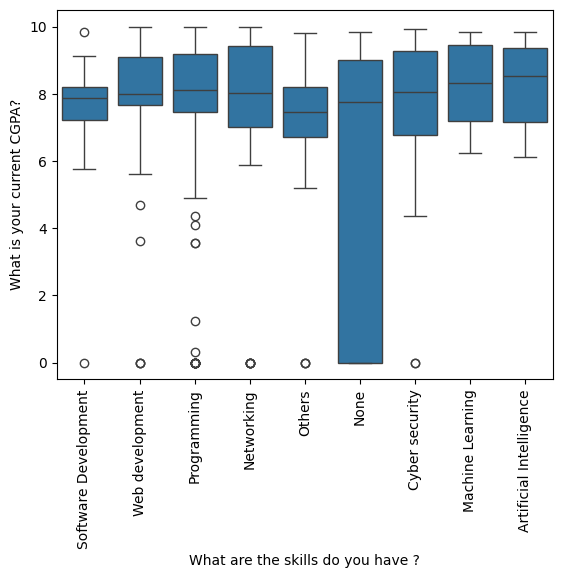

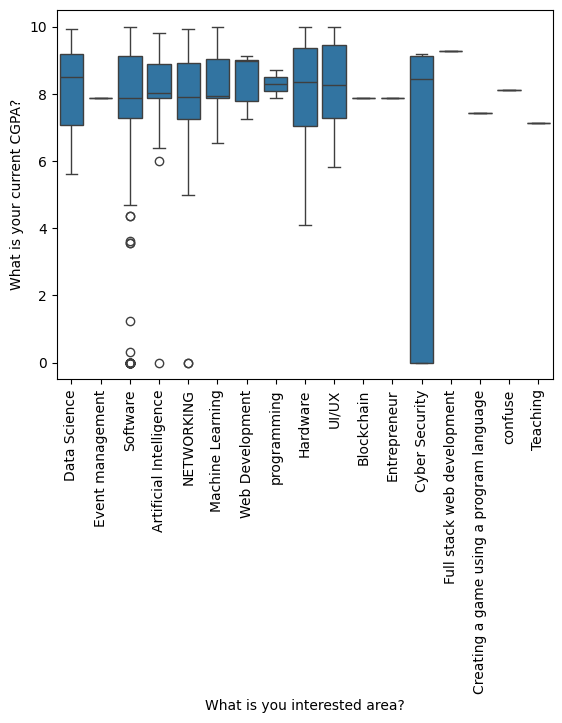

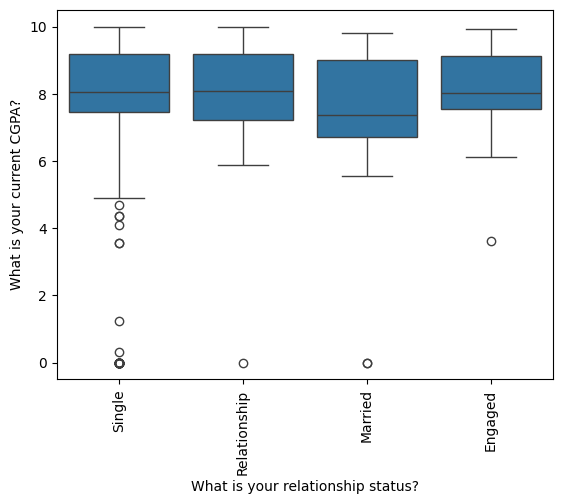

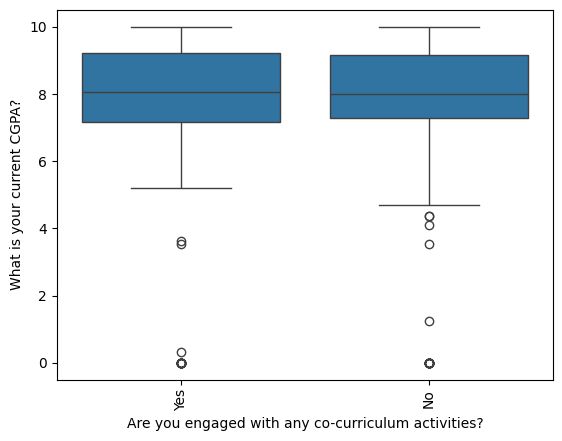

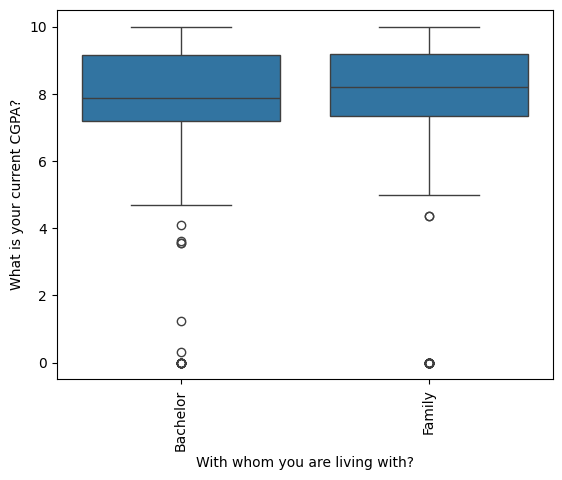

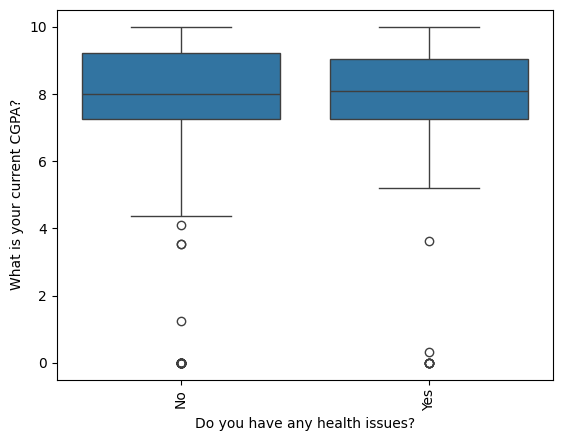

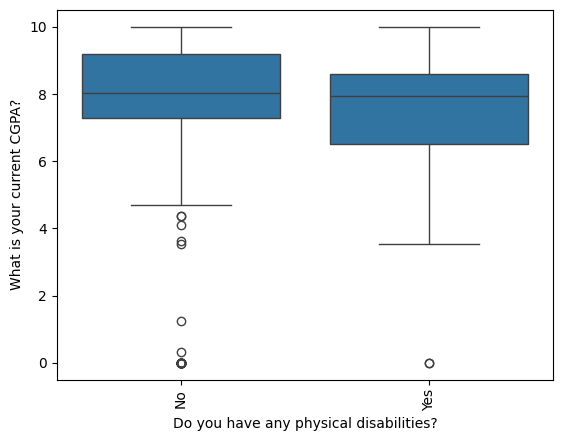

In [92]:
# maiking boxplot of categorical columns with target column 
for i in categorical:
    sns.boxplot(x=df[i],y=df['What is your current CGPA?'])
    plt.xticks(rotation = 90)
    plt.show()

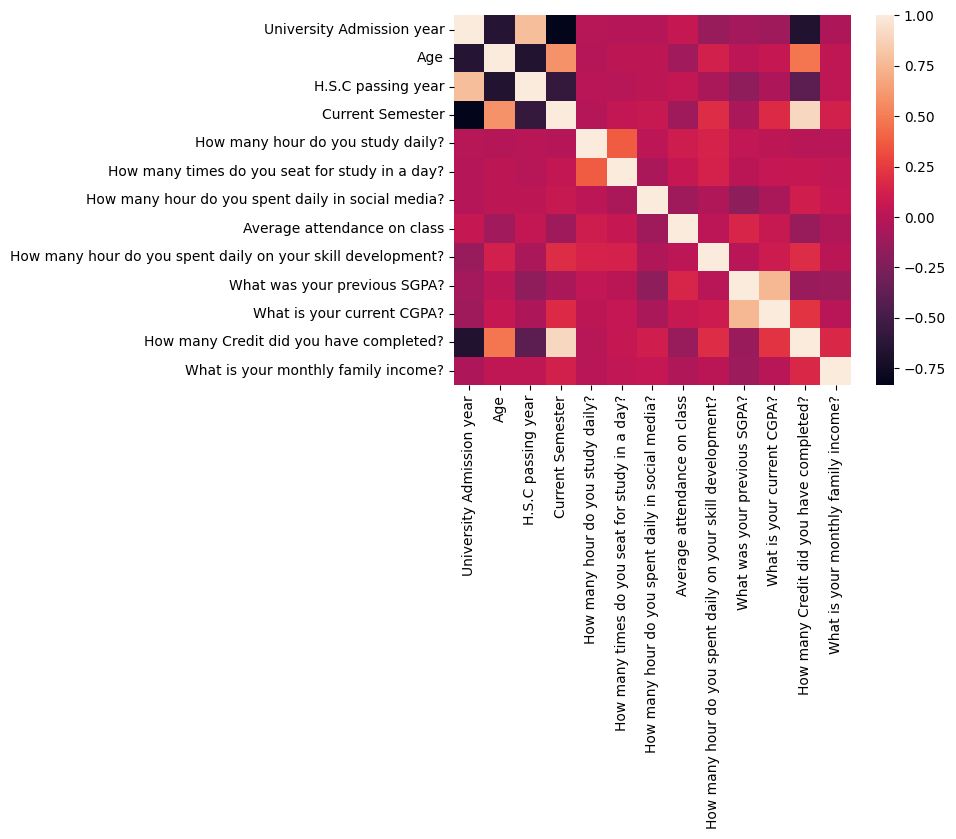

In [99]:
# making heatmap 
sns.heatmap(df[numcol].corr())
plt.show()

In [103]:
corr = df.corr(numeric_only=True)

In [104]:
corr['What is your current CGPA?'].sort_values(ascending=True)

University Admission year                                     -0.110226
How many hour do you spent daily in social media?             -0.053872
H.S.C passing year                                            -0.052568
What is your monthly family income?                           -0.002344
How many hour do you study daily?                              0.019135
How many times do you seat for study in a day?                 0.049428
Age                                                            0.061377
Average attendance on class                                    0.068017
How many hour do you spent daily on your skill development?    0.083263
Current Semester                                               0.174097
How many Credit did you have completed?                        0.218561
What was your previous SGPA?                                   0.752828
What is your current CGPA?                                     1.000000
Name: What is your current CGPA?, dtype: float64

In [105]:
# now most of the eda and cleaning is done but we will do some more cleaning of the data which will give use better results for our model 
df.head().T

,0,1,2,3,4
University Admission year,2018,2021,2020,2021,2021
Gender,Male,Male,Female,Male,Male
Age,24,22,21,20,22
H.S.C passing year,2016,2020,2019,2020,2019
Current Semester,12,4,5,4,4
Do you have meritorious scholarship ?,Yes,Yes,No,Yes,Yes
Do you use University transportation?,No,Yes,No,No,No
How many hour do you study daily?,3,3,3,1,3
How many times do you seat for study in a day?,2,2,3,3,1
What is your preferable learning mode?,Offline,Online,Offline,Offline,Online
